#📌 Extracción

Preparación del entorno de trabajo con las librerías necesarias y la carga del archivo desde la fuente.

In [10]:
import os
import json
import pandas as pd

Verificar el directorio actual de trabajo

In [11]:
print("Directorio actual:", os.getcwd())

Directorio actual: /content


Extraer el JSON

In [13]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
data = json.loads(requests.get(url).text)
df = pd.DataFrame(data)

In [14]:
df_original = pd.DataFrame(data)

Primeras 5 filas

In [15]:
df_original.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

Crear una copia del DataFrame original para desanidar columnas compuestas

In [16]:
df_transformado = df_original.copy()

In [17]:
# Lista de columnas detectadas en exploracion
columnas_con_dict = ['customer', 'phone', 'internet', 'account']

# Expandir columnas
for columna in columnas_con_dict:
    columnas_expandida = pd.json_normalize(df_transformado[columna])
    columnas_expandida.columns = [f"{columna}.{subcol}" for subcol in columnas_expandida.columns]

    df_transformado = pd.concat([df_transformado, columnas_expandida], axis=1)
    df_transformado.drop(columns=[columna], inplace=True)

# Mostrar columnas
print("Columnas después de desanidar:")
print(df_transformado.columns)

Columnas después de desanidar:
Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


In [18]:
df_transformado.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Renombrar columnas reemplazando puntos por guiones bajos

In [20]:
df_transformado.columns = [col.replace('.', '_') for col in df_transformado.columns]
duplicados = df_transformado.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

Número de filas duplicadas: 0


Convertir columnas numéricas que pueden estar como texto

In [21]:
df_transformado['account_Charges_Monthly'] = pd.to_numeric(df_transformado['account_Charges_Monthly'], errors='coerce')
df_transformado['account_Charges_Total'] = pd.to_numeric(df_transformado['account_Charges_Total'], errors='coerce')

Crear una nueva columna para cálculo diario

In [22]:
df_transformado['Cuentas_Diarias'] = df_transformado['account_Charges_Monthly'] / 30

Convertir columnas categóricas tipo "Yes"/"No" a 1/0 (Churn)

In [23]:
columnas_binarias = [
    'customer_Partner', 'customer_Dependents',
    'phone_PhoneService', 'phone_MultipleLines',
    'internet_OnlineSecurity', 'internet_OnlineBackup',
    'internet_DeviceProtection', 'internet_TechSupport',
    'internet_StreamingTV', 'internet_StreamingMovies',
    'account_PaperlessBilling'
]

for col in columnas_binarias:
    df_transformado[col] = df_transformado[col].map({'Yes': 1, 'No': 0})

df_transformado['Churn'] = df_transformado['Churn'].map({'Yes': 1, 'No': 0})

#📊 Carga y análisis

Distribucion de la variable Churn

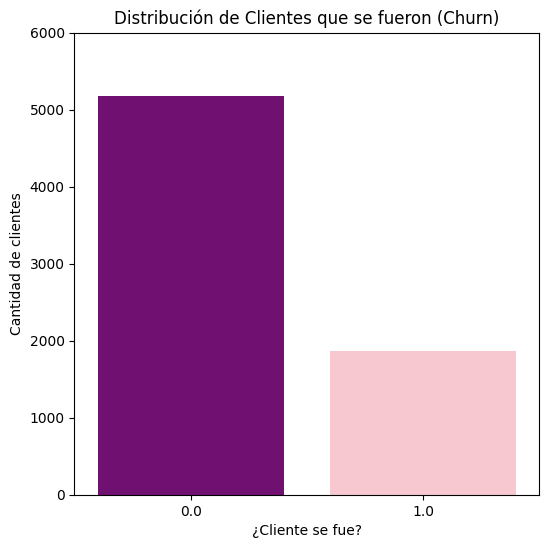

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

sns.countplot(
    data=df_transformado,
    x='Churn',
    hue='Churn',
    palette={0: 'purple', 1: 'pink'},
    legend=False
)

# Título y etiquetas
plt.title('Distribución de Clientes que se fueron (Churn)')
plt.xlabel('¿Cliente se fue?')
plt.ylabel('Cantidad de clientes')

plt.ylim(0, 6000)

plt.show()

Analisis por tipo de contrato

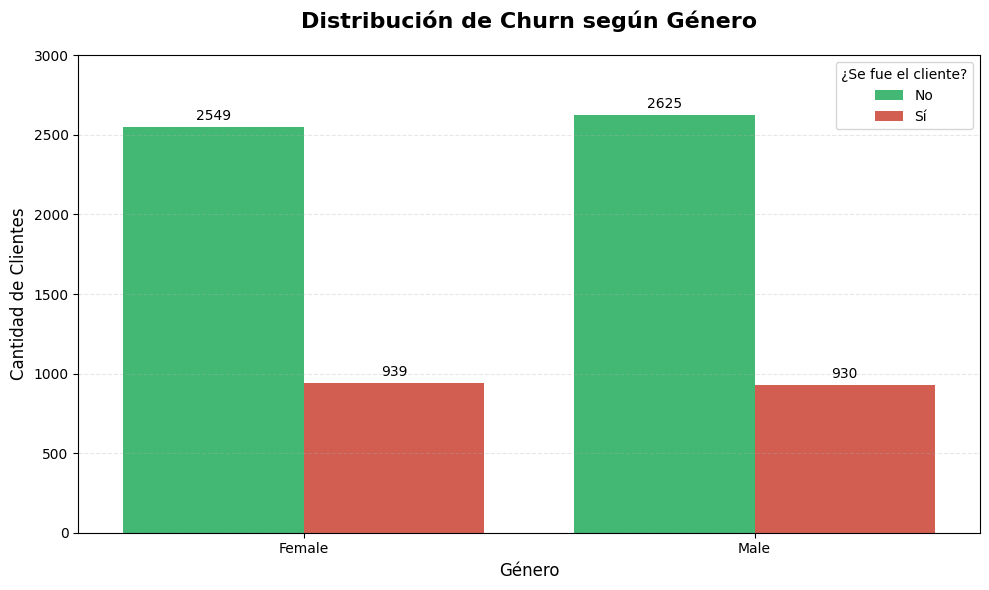

In [33]:
df_transformado['Churn_Label'] = df_transformado['Churn'].map({0: 'No', 1: 'Sí'})

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df_transformado, x='customer_gender', hue='Churn_Label',
              palette=['#2ecc71', '#e74c3c'], ax=ax)

plt.title('Distribución de Churn según Género', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.legend(title='¿Se fue el cliente?', loc='upper right', fontsize=10)
plt.ylim(0, 3000)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

# Análisis por tipo de contrato

Verificar si existen diferntes tipos de contratos

In [30]:
print(df_transformado['account_Contract'].unique())

['One year' 'Month-to-month' 'Two year']


['One year' 'Month-to-month' 'Two year']


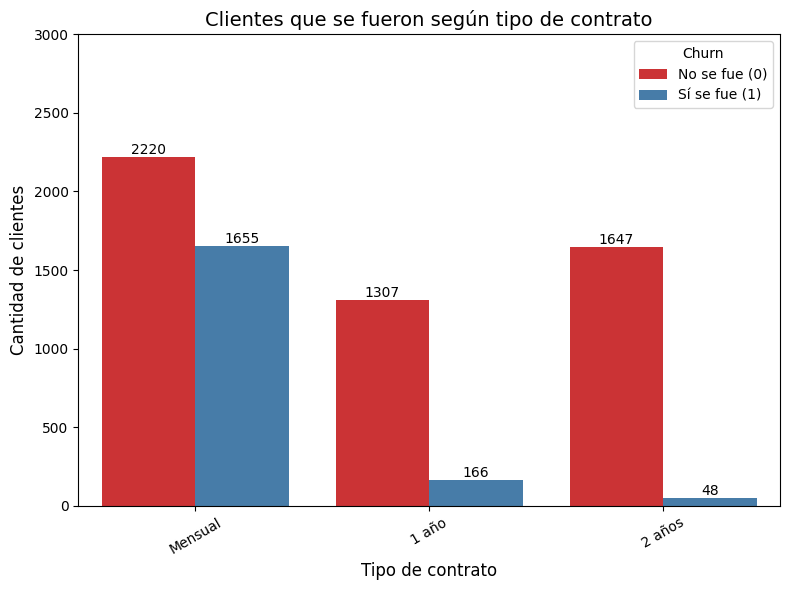

In [31]:
print(df_transformado['account_Contract'].unique())

orden_contratos = ['Mensual', '1 año', '2 años']

df_transformado['account_Contract'] = df_transformado['account_Contract'].replace({
    'Month-to-month': 'Mensual',
    'One year': '1 año',
    'Two year': '2 años'
})

plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df_transformado,
    x='account_Contract',
    hue='Churn',
    palette='Set1',
    order=orden_contratos
)

plt.title('Clientes que se fueron según tipo de contrato', fontsize=14)
plt.xlabel('Tipo de contrato', fontsize=12)
plt.ylabel('Cantidad de clientes', fontsize=12)

plt.xticks(rotation=30)

plt.legend(
    title='Churn',
    labels=['No se fue (0)', 'Sí se fue (1)']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

plt.ylim(0, 3000)
plt.tight_layout()
plt.show()

Análisis por método de pago

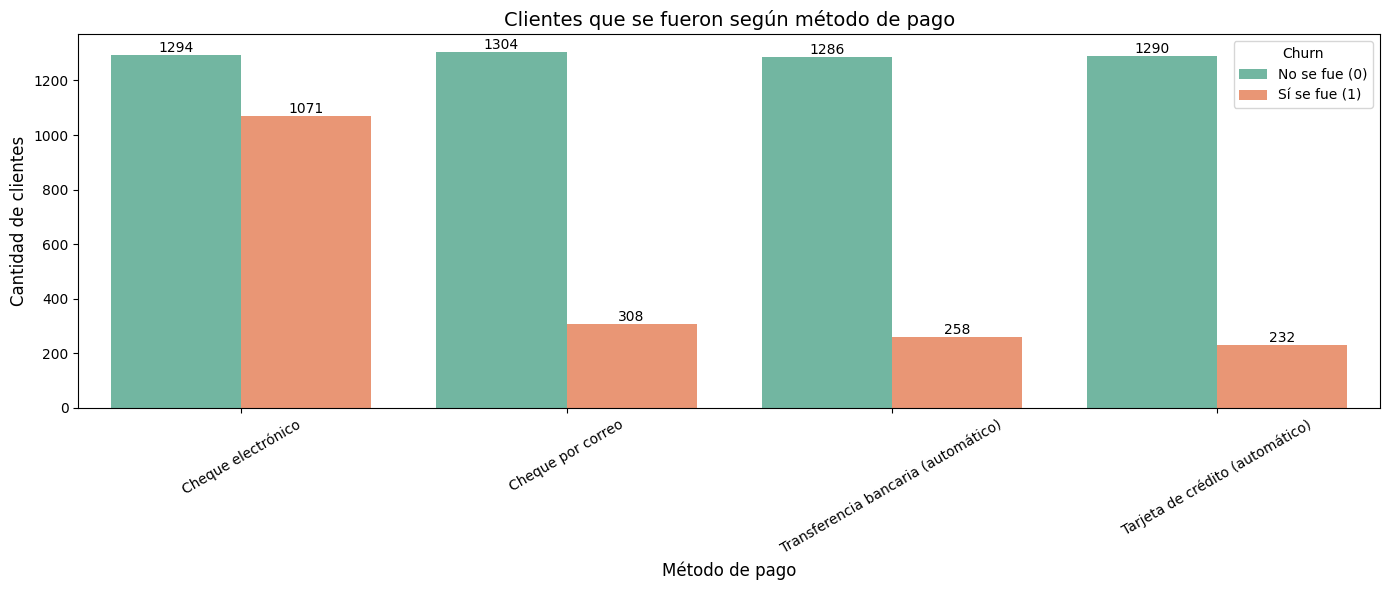

In [32]:
orden_metodos = [
    'Cheque electrónico',
    'Cheque por correo',
    'Transferencia bancaria (automático)',
    'Tarjeta de crédito (automático)'
]


df_transformado['account_PaymentMethod'] = df_transformado['account_PaymentMethod'].replace({
    'Mailed check': 'Cheque por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automático)'
})

plt.figure(figsize=(14, 6))

ax = sns.countplot(
    data=df_transformado,
    x='account_PaymentMethod',
    hue='Churn',
    palette='Set2',
    order=orden_metodos
)

plt.title('Clientes que se fueron según método de pago', fontsize=14)
plt.xlabel('Método de pago', fontsize=12)
plt.ylabel('Cantidad de clientes', fontsize=12)
plt.xticks(rotation=30)

plt.legend(
    title='Churn',
    labels=['No se fue (0)', 'Sí se fue (1)']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

plt.tight_layout()
plt.show()

#📄Informe final

La situación de TelecomX revela un desafío significativo en términos de retención de clientes. Con aproximadamente un 26.5% de tasa de abandono, la compañía está perdiendo más de uno de cada cuatro clientes, lo cual representa una señal de alerta que requiere atención inmediata. Sin embargo, al analizar los datos en profundidad, encontramos patrones claros que no solo explican por qué los clientes se van, sino que también señalan caminos concretos hacia la solución.

Lo interesante de este panorama es que la fuga no es un fenómeno homogéneo ni aleatorio. Los datos muestran que ciertos grupos de clientes tienen una probabilidad dramáticamente mayor de abandonar el servicio, mientras que otros permanecen con tasas de lealtad excepcionales. Esta variabilidad sugiere que el problema no radica en la calidad general del servicio o en factores externos del mercado, sino en aspectos estructurales específicos de cómo TelecomX organiza sus contratos y métodos de pago



---


# Genero
Las mujeres abandonan al 26.9% y los hombres al 26.2%, una diferencia insignificante. Esto libera a TelecomX de desarrollar estrategias diferenciadas por género y confirma que los problemas de retención afectan a todos por igual. Los recursos pueden dirigirse a factores que realmente importan en lugar de segmentaciones demográficas innecesarias.

---
# Tipo de contrato
Los contratos mensuales presentan 42.7% de abandono versus apenas 2.8% en contratos de dos años. Esta diferencia abismal revela que los clientes mensuales evalúan constantemente si continuar, creando múltiples "puntos de salida". Cada mes se convierte en una oportunidad para reconsiderar, comparar con la competencia, y cancelar ante cualquier insatisfacción menor.

Los contratos largos funcionan diferente: el compromiso inicial crea barreras psicológicas y económicas para salir. Los clientes racionalizan pequeñas molestias porque ya tomaron una decisión de largo plazo. Además, estos contratos suelen incluir beneficios que el cliente no quiere perder, actuando como anclas emocionales de retención.

---
# Metodo de pago
El cheque electrónico (45.3% de abandono) contrasta dramáticamente con métodos automáticos (15-17%). Cada vez que un cliente debe pagar manualmente, enfrenta un momento de fricción que se convierte en momento de reflexión: "¿Realmente necesito esto? ¿Hay algo mejor?". Los pagos automáticos eliminan esta ceremonia mensual de cuestionamiento.

Además, la automatización previene olvidos que pueden desencadenar suspensiones de servicio, frustraciones y cancelaciones definitivas. El servicio simplemente continúa, invisible pero constante, sin generar momentos críticos de decisión. Esta "invisibilidad operacional" es paradójicamente la clave de la retención.

---
# Concluciones

Prioridad 1: Crear diferencias de precio significativas (30-40% más caro) para contratos mensuales, reflejando sus costos reales de retención. Ofrecer incentivos agresivos (2 meses gratis, 20% descuento anual) para migrar a contratos anuales.

Prioridad 2: Hacer el débito automático la opción predeterminada en nuevos registros. Para clientes existentes, ofrecer 1-2 meses gratis por configurar pago automático. El costo de este incentivo es mínimo comparado con los costos de reemplazar clientes perdidos.

Prioridad 3: Identificar proactivamente clientes mensuales con cheque electrónico y contactarlos con ofertas personalizadas antes de que cancelen.
